<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/borges/RA1_LAB1/Datos_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiencia 1: Sistema de alerta temprana ACV en atención primaria

##Librerias Generales a importar y carga de dataset

In [ ]:
# Importación, visualización, manipulación de datos
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
import warnings
from sklearn.impute import KNNImputer


warnings.filterwarnings('ignore') # Mantenemos los logs limpios


In [ ]:
!wget https://github.com/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB1/datos_acv.csv

--2026-04-08 00:13:30--  https://github.com/Santibareiro27/Inteligencia-Computacional/blob/main/RA1_LAB1/datos_acv.csv
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘datos_acv.csv.24’

datos_acv.csv.24        [  <=>               ]   2.55M  12.7MB/s    in 0.2s    

2026-04-08 00:13:32 (12.7 MB/s) - ‘datos_acv.csv.24’ saved [2678612]



##1. Análisis Exploratorio de Datos (EDA)

In [ ]:
# Lectura del dataset
df_acv = pd.read_csv("datos_acv.csv")
df_acv

,id,genero,edad,hipertension,enfermedad_corazon,casado_alguna_vez,tipo_trabajo,tipo_residencia,nivel_glucosa,imc,estado_fumador,apoplejia
0,9046,hombre,67.0,0,1,1,privado,urbano,228.69,36.6,fumaba,1
1,51676,mujer,61.0,0,0,1,autonomo,rural,202.21,NaN,nunca,1
2,31112,hombre,80.0,0,1,1,privado,rural,105.92,32.5,nunca,1
3,60182,mujer,49.0,0,0,1,privado,urbano,171.23,34.4,fuma,1
4,1665,mujer,79.0,1,0,1,autonomo,rural,174.12,24.0,nunca,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,mujer,80.0,1,0,1,privado,urbano,83.75,NaN,nunca,0
5106,44873,mujer,81.0,0,0,1,autonomo,urbano,125.20,40.0,nunca,0
5107,19723,mujer,35.0,0,0,1,autonomo,rural,82.99,30.6,nunca,0
5108,37544,hombre,51.0,0,0,1,privado,rural,166.29,25.6,fumaba,0


In [ ]:
#visualización de tipos de datos, cantidades y valores faltantes
df_acv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5110 non-null   int64  
 1   genero              5110 non-null   object 
 2   edad                5110 non-null   float64
 3   hipertension        5110 non-null   int64  
 4   enfermedad_corazon  5110 non-null   int64  
 5   casado_alguna_vez   5110 non-null   int64  
 6   tipo_trabajo        5110 non-null   object 
 7   tipo_residencia     5110 non-null   object 
 8   nivel_glucosa       5110 non-null   float64
 9   imc                 4909 non-null   float64
 10  estado_fumador      5110 non-null   object 
 11  apoplejia           5110 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 479.2+ KB


In [ ]:
# Cálculo de valores faltantes y porcentajes por columna
faltantes = df_acv.isnull().sum()
porcentaje = (df_acv.isnull().sum() / len(df_acv) * 100).round(2)

# Creación de tabla resumen
resumen_nulos = pd.DataFrame({
    'Valores Faltantes': faltantes,
    'Porcentaje (%)': porcentaje
})

print("Resumen de datos faltantes por columna:")
print(resumen_nulos)

Resumen de datos faltantes por columna:
                    Valores Faltantes  Porcentaje (%)
id                                  0            0.00
genero                              0            0.00
edad                                0            0.00
hipertension                        0            0.00
enfermedad_corazon                  0            0.00
casado_alguna_vez                   0            0.00
tipo_trabajo                        0            0.00
tipo_residencia                     0            0.00
nivel_glucosa                       0            0.00
imc                               201            3.93
estado_fumador                      0            0.00
apoplejia                           0            0.00


Tras ejecutar `df_acv.info()` y el resumen de nulos, se extraen las siguientes observaciones:

1. **Dimensión del Dataset**: El conjunto de datos cuenta con **5110 registros** y **12 columnas** (features).
2. **Tipos de Datos**:
   * **Numéricos**: Contamos con variables de tipo flotante (`edad`, `nivel_glucosa`, `imc`) y enteras (`id`, `hipertension`, `enfermedad_corazon`, `casado_alguna_vez`, `apoplejia`).
   * **Categóricos (Object)**: Las variables `genero`, `tipo_trabajo`, `tipo_residencia` y `estado_fumador` requerirán preprocesamiento (como encoding) para ser utilizadas en modelos de machine learning.
3. **Valores Faltantes**:
   * La variable **`imc`** es la única que presenta valores nulos: **201 registros (3.93%)**.
   * Dado que el porcentaje es relativamente bajo (menor al 5%), se podría optar por técnicas de imputación (media, mediana) o eliminación de esas filas según el impacto en el modelo.
4. **Variable Objetivo**: La columna `apoplejia` es nuestra variable target, la cual es binaria (0 y 1).

In [ ]:
pacientes_encontrados = []

for index, row in df_acv.iterrows():
    # Condición: IMC es nulo O estado_fumador es 'desconocido'
    if pd.isna(row['imc']) or row['estado_fumador'] == 'desconocido':
        pacientes_encontrados.append({
            'id': row['id'],
            'imc': row['imc'],
            'estado_fumador': row['estado_fumador'],
            'apoplejia': row['apoplejia']
        })

    if len(pacientes_encontrados) == 4:
        break

# Crear el DataFrame con los resultados de la búsqueda
df_resultados = pd.DataFrame(pacientes_encontrados)
display(df_resultados)

,id,imc,estado_fumador,apoplejia
0,51676,NaN,nunca,1
1,27419,NaN,desconocido,1
2,60491,24.2,desconocido,1
3,8213,NaN,desconocido,1


EN medicina, un dato faltante casi nunca es un "error del sistema", Es información en el contexto. Como se observa en la tabla superior, el paciente con ID `60491` tiene su estado de fumador como `desconocido`, pese a haber sufrido un AVC, de manera similar, lo mismo ocurre con el paciente con id `51676` no tiene un valor cargado de `imc` y también sufrió un ACV.
Si se busca eliminar estas filas con datos faltantes o desconocidos, se estarían eliminando a pacientes críticos que justamente se buscan predecir, y por ende, sesganso el modelo.

###Análisis de IMC

A partir del siguiente gráfico de barras de valores de IMC faltantes por Rango de edad, se puede ver un desbalance de

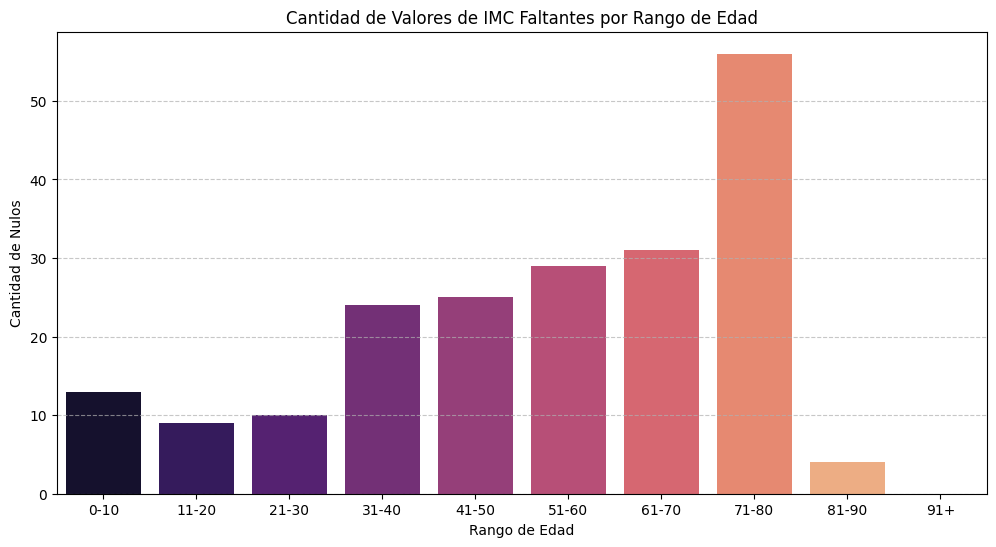

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear rangos de edad (bins) para agrupar de forma temporal para el gráfico
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91+']

# 2. Filtrar solo los registros donde el IMC es nulo y asignar el rango temporalmente
df_nulos = df_acv[df_acv['imc'].isnull()].copy()
df_nulos['rango_visualizacion'] = pd.cut(df_nulos['edad'], bins=bins, labels=labels, right=False)

# 3. Graficar la frecuencia de nulos por rango de edad
plt.figure(figsize=(12, 6))
sns.countplot(data=df_nulos, x='rango_visualizacion', palette='magma', order=labels)

plt.title('Cantidad de Valores de IMC Faltantes por Rango de Edad')
plt.xlabel('Rango de Edad')
plt.ylabel('Cantidad de Nulos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Para evitar sesgos al imputar valores faltantes de este feature con valores como la media o mediana, se realiza una imputación por el método KNN, utilizando como columnas a evaluar `edad` y `género`, para esto primeramente se realiza un análisis de datos del feature `género`:

In [ ]:
# Mostrar los valores únicos y su frecuencia para el feature 'genero'
variaciones_genero = df_acv['genero'].value_counts()
print("Variaciones y conteo del feature 'genero':")
print(variaciones_genero)

Variaciones y conteo del feature 'genero':
genero
mujer     2994
hombre    2115
otro         1
Name: count, dtype: int64


Se observa un paciente con un género `otro`:

In [ ]:
# Filtrar el registro con género 'otro'
df_otro = df_acv[df_acv['genero'] == 'otro']

# Calcular el porcentaje que representa frente al total
porcentaje_otro = (len(df_otro) / len(df_acv)) * 100

print(f"El paciente con género 'otro' representa el {porcentaje_otro:.4f}% del total de pacientes ({len(df_acv)}).")
display(df_otro)

El paciente con género 'otro' representa el 0.0196% del total de pacientes (5110).


,id,genero,edad,hipertension,enfermedad_corazon,casado_alguna_vez,tipo_trabajo,tipo_residencia,nivel_glucosa,imc,estado_fumador,apoplejia
3116,56156,otro,26.0,0,0,0,privado,rural,143.33,22.4,fumaba,0


Bajo estas observaciones, este paciente debería ser descartado por que no representa un porcentaje significativo (0,0196%) frente al total de pacientes, además, como no representa apoplejia positiva, no es un paciente crítico.

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Guardar el dataset actual en df_acvClean
df_acvClean = df_acv.copy()

# 2. Eliminar el paciente con género "otro"
df_acvClean = df_acvClean[df_acvClean['genero'] != 'otro']

# 3. Codificar por One Hot Encoding el feature "genero" en 1/0
df_acvClean = pd.get_dummies(df_acvClean, columns=['genero'], prefix='genero', dtype=int)

# 4. Escalar los datos antes de la imputación KNN
# (KNN depende de distancias, por lo que la escala es crítica)
columnas_para_knn = ['edad', 'genero_hombre', 'genero_mujer', 'imc']
scaler = StandardScaler()
df_acv_subset = df_acvClean[columnas_para_knn].copy()

# Ajustamos el escalador con el subconjunto de columnas relevantes
df_scaled = pd.DataFrame(scaler.fit_transform(df_acv_subset), columns=columnas_para_knn)

# 5. Realizar imputación KNN sobre los datos escalados
imputer = KNNImputer(n_neighbors=5)
df_imputado_scaled = imputer.fit_transform(df_scaled)

# 6. Deshacer el escalado para volver a los valores originales
df_final_values = scaler.inverse_transform(df_imputado_scaled)
df_acvClean[columnas_para_knn] = df_final_values

# 7. Limpieza final: convertir las columnas de género de nuevo a enteros y redondear IMC
df_acvClean[['genero_hombre', 'genero_mujer']] = df_acvClean[['genero_hombre', 'genero_mujer']].astype(int)
df_acvClean['imc'] = df_acvClean['imc'].round(2)

# Verificación de resultados
print(f"Nulos en IMC después de imputar: {df_acvClean['imc'].isnull().sum()}")
display(df_acvClean.head())

Nulos en IMC después de imputar: 0


,id,edad,hipertension,enfermedad_corazon,casado_alguna_vez,tipo_trabajo,tipo_residencia,nivel_glucosa,imc,estado_fumador,apoplejia,genero_hombre,genero_mujer
0,9046,67.0,0,1,1,privado,urbano,228.69,36.60,fumaba,1,1,0
1,51676,61.0,0,0,1,autonomo,rural,202.21,26.38,nunca,1,0,1
2,31112,80.0,0,1,1,privado,rural,105.92,32.50,nunca,1,1,0
3,60182,49.0,0,0,1,privado,urbano,171.23,34.40,fuma,1,0,1
4,1665,79.0,1,0,1,autonomo,rural,174.12,24.00,nunca,1,0,1
